# Descriptive Analysis
**summarizes and describes what the data shows — counts, rates, averages, and distributions without explaining why it happens or predicting what will happen next.**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [28]:
#For the EDA (Exploratory Data Analysis)

In [29]:
df_master = pd.read_csv("cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv")

In [30]:
print("Shape:", df_master.shape)

Shape: (2008, 200)


In [31]:
df_master.head()

,inpatient_number,gender,weight,height,bmi,occupation,agecat,flag_invalid_height,flag_invalid_weight,bmi_category,...,congestive_heart_failure,peripheral_vascular_disease,type_of_heart_failure,lvef,left_ventricular_end_diastolic_diameter_lv,mitral_valve_ems,mitral_valve_ams,ea,tricuspid_valve_return_velocity,tricuspid_valve_return_pressure
0,827040,Female,50.0,1.45,23.781213,Unspecified,69-79,False,False,Normal,...,1,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,857781,Male,50.0,1.64,18.590125,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,743087,Female,51.0,1.63,19.195303,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,40.0,1.16,1.52,NaN,3.34,47.0
3,866418,Male,70.0,1.70,24.221453,Farmer,59-69,False,False,Normal,...,0,0,Both,NaN,46.0,0.84,0.12,7.0,2.80,32.0
4,775928,Male,65.0,1.70,22.491349,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Columns: 200 entries, inpatient_number to tricuspid_valve_return_pressure
dtypes: bool(2), float64(148), int64(35), str(15)
memory usage: 3.3 MB


In [33]:
df_master.dtypes

inpatient_number                     int64
gender                                 str
weight                             float64
height                             float64
bmi                                float64
                                    ...   
mitral_valve_ems                   float64
mitral_valve_ams                   float64
ea                                 float64
tricuspid_valve_return_velocity    float64
tricuspid_valve_return_pressure    float64
Length: 200, dtype: object

## Q1:What is the distribution of key lab markers — BNP, creatinine, hemoglobin, sodium, potassium —and what proportion of patients fall outside normal clinical reference ranges

**Reasoning:** Combining distribution stats and reference-range comparison into one tidy table avoids scanning multiple separate printouts.Adding a color gradient to the "% Outside range" column draws the eye directly to the most abnormal labs without requiring the reader to parse every number.

In [34]:
import pandas as pd

def pct_outside_combined(gender_col, values, ranges_by_gender):
    """Combines sex-specific reference ranges into one overall % outside, weighted correctly."""
    out, n = 0, 0
    for g, (low, high) in ranges_by_gender.items():
        v = values[(gender_col == g) & values.notna()]
        out += ((v < low) | (v > high)).sum()
        n += v.shape[0]
    return round(out / n * 100, 1), n

rows = []

# Labs with a single reference range for everyone
single_range_labs = [
    ("brain_natriuretic_peptide", 0, 100, "pg/mL", "< 100 pg/mL"),
    ("sodium", 135, 145, "mmol/L", "135-145 mmol/L"),
    ("potassium", 3.5, 5.1, "mmol/L", "3.5-5.1 mmol/L"),
]
for lab, low, high, unit, label in single_range_labs:
    s = df_master[lab].dropna()
    pct = round((((s < low) | (s > high)).mean()) * 100, 1)
    rows.append({
        "Lab": lab.replace("_", " ").title(),
        "n": s.shape[0],
        "Mean": round(s.mean(), 1),
        "Median": round(s.median(), 1),
        "IQR": round(s.quantile(0.75) - s.quantile(0.25), 1),
        "Reference range": label,
        "% Outside range": pct,
    })

# Labs with sex-specific reference ranges
gender_ranges = {
    "hemoglobin": {"Male": (130, 175), "Female": (115, 150)},
    "creatinine_enzymatic_method": {"Male": (62, 106), "Female": (44, 97)},
}
units = {"hemoglobin": "g/L", "creatinine_enzymatic_method": "umol/L"}

for lab, ranges in gender_ranges.items():
    s = df_master[lab].dropna()
    pct, n = pct_outside_combined(df_master["gender"], df_master[lab], ranges)
    rows.append({
        "Lab": lab.replace("_", " ").title(),
        "n": s.shape[0],
        "Mean": round(s.mean(), 1),
        "Median": round(s.median(), 1),
        "IQR": round(s.quantile(0.75) - s.quantile(0.25), 1),
        "Reference range": f"M {ranges['Male'][0]}-{ranges['Male'][1]} / F {ranges['Female'][0]}-{ranges['Female'][1]} {units[lab]}",
        "% Outside range": pct,
    })

table = pd.DataFrame(rows)
table
table.style.background_gradient(subset=["% Outside range"], cmap="Reds").format({"% Outside range": "{:.1f}"})

,Lab,n,Mean,Median,IQR,Reference range,% Outside range
0,Brain Natriuretic Peptide,1973,1280.400000,753.000000,1434.600000,< 100 pg/mL,92.5
1,Sodium,1997,138.200000,139.000000,5.400000,135-145 mmol/L,22.4
2,Potassium,1997,4.000000,3.900000,0.800000,3.5-5.1 mmol/L,29.6
3,Hemoglobin,1980,115.100000,117.000000,30.000000,M 130-175 / F 115-150 g/L,57.0
4,Creatinine Enzymatic Method,1985,108.900000,87.100000,57.800000,M 62-106 / F 44-97 umol/L,43.9


**Key Insight:** BNP stands out as the clear outlier at 92.5% outside range, visually distinct from every other lab in the table.Hemoglobin and creatinine form a mid-tier abnormality group, while sodium and potassium show the least deviation — cardiac stress and renal/hematologic dysfunction dominate over electrolyte imbalance in this cohort.

## Q2: What is the observed 6-month death rate within each combination of Killip grade level and ICU/non-ICU admission?


**Reasoning:** Killip grade and ICU status are independent severity markers that move in the same direction, so their agreement strengthens confidence in the pattern, while the large stable subgroups (n=1,547, n=446) carry the statistical weight and the tiny ICU cells (n=6, n=9) are noted only for directional consistency.

In [38]:
df_master["high_killip"] = df_master["killip_grade"] >= 3
df_master["icu"] = df_master["admission_ward"] == "ICU"

grp = df_master.groupby(["high_killip", "icu"])["death_within_6_months"].agg(["count", "mean"])
grp["mean"] *= 100
print(grp)

                   count       mean
high_killip icu                    
False       False   1547   1.228184
            True       9  11.111111
True        False    446   8.071749
            True       6  16.666667


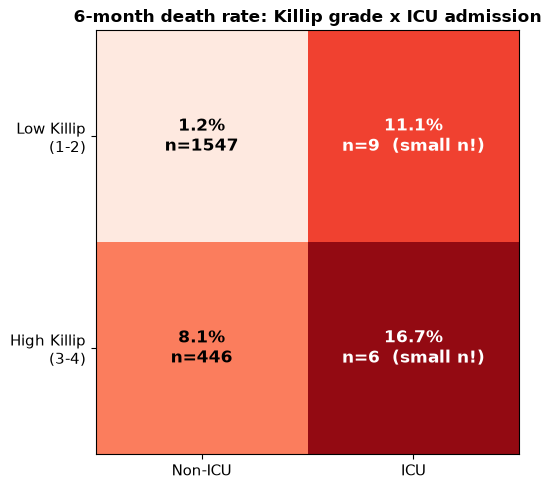

In [39]:
mat = np.array([[grp.loc[(False, False), "mean"], grp.loc[(False, True), "mean"]],
                [grp.loc[(True, False), "mean"],  grp.loc[(True, True), "mean"]]])
ns_mat = np.array([[grp.loc[(False, False), "count"], grp.loc[(False, True), "count"]],
                    [grp.loc[(True, False), "count"],  grp.loc[(True, True), "count"]]])

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(mat, cmap="Reds", vmin=0, vmax=mat.max()*1.1)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Non-ICU", "ICU"], fontsize=11)
ax.set_yticks([0, 1]); ax.set_yticklabels(["Low Killip\n(1-2)", "High Killip\n(3-4)"], fontsize=11)
for i in range(2):
    for j in range(2):
        n = ns_mat[i, j]
        note = "  (small n!)" if n < 20 else ""
        ax.text(j, i, f"{mat[i,j]:.1f}%\nn={n}{note}", ha="center", va="center",
                fontsize=12, fontweight="bold", color="white" if mat[i,j]>mat.max()*0.5 else "black")
ax.set_title("6-month death rate: Killip grade x ICU admission", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()



**Key insight:** Key insight: Death risk climbs in step with severity — 1.2% (low Killip, non-ICU) → 8.1% (high Killip, non-ICU) → 16.7% (high Killip + ICU, small sample).

## Q3.What is the distribution of heart failure phenotype (Right/Left/both), NYHA class, and Killip grade?

**Reasoning:** Phenotype (Left/Right/Biventricular), NYHA class, and Killip grade are the standard clinical severity/type classifications for heart failure — knowing their spread tells us what kind of dataset we're working with (e.g., mostly severe biventricular failure vs. mild left-sided cases) and sets the baseline for interpreting every other outcome.

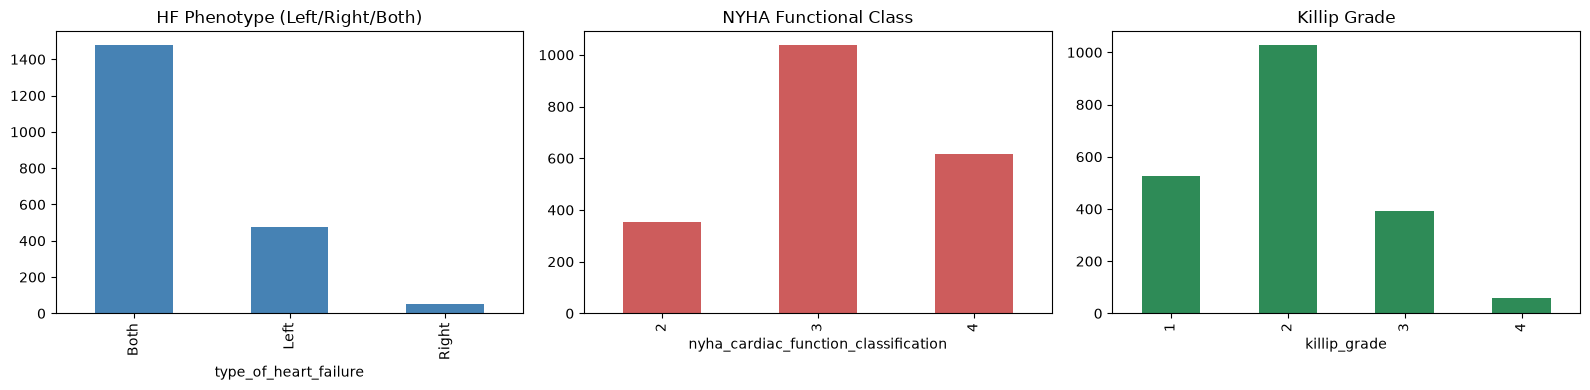

type_of_heart_failure
type_of_heart_failure
Both     73.7
Left     23.8
Right     2.5
Name: proportion, dtype: float64

nyha_cardiac_function_classification
nyha_cardiac_function_classification
3    51.7
4    30.7
2    17.6
Name: proportion, dtype: float64

killip_grade
killip_grade
2    51.2
1    26.2
3    19.5
4     3.0
Name: proportion, dtype: float64



In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_master['type_of_heart_failure'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('HF Phenotype (Left/Right/Both)')

df_master['nyha_cardiac_function_classification'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('NYHA Functional Class')

df_master['killip_grade'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Killip Grade')

plt.tight_layout(); plt.show()

for col in ['type_of_heart_failure', 'nyha_cardiac_function_classification', 'killip_grade']:
    print(col)
    print((df_master[col].value_counts(normalize=True).mul(100).round(1)))
    print()

**Insights:**
1.Phenotype: ~3 in 4 patients have both sides of the heart failing — a more advanced form, not an early-stage one.
2.NYHA class: No one arrived with mild symptoms; 8 in 10 were already badly limited — breathless with little effort or even at rest.
3.Killip grade: Most arrived in mild-to-moderate shape, but about 1 in 4 already showed signs of fluid in the lungs or shock.


## Q4. How do admission pathway (emergency vs. non-emergency), admission ward, and discharge destination distribute across the dataset?

**Reasoning:** How a patient enters the hospital (emergency vs. planned) and where they're placed (cardiology, ICU, general ward) reflects how unstable they were at the door; where they end up (home, another facility, or death) reflects how the admission actually went. Together these three fields sketch the patient's whole journey — entry severity → level of care received → exit status — which is essential context before you interpret any lab value or outcome in isolation.

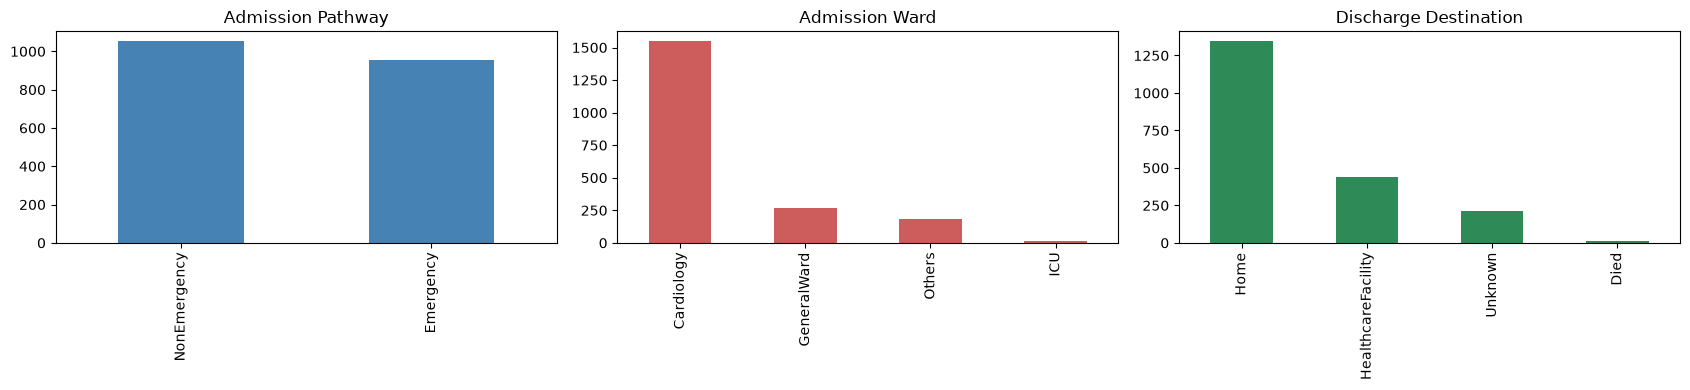


admission_way
admission_way
NonEmergency    52.4
Emergency       47.6
Name: proportion, dtype: float64

admission_ward
admission_ward
Cardiology     77.0
GeneralWard    13.2
Others          9.0
ICU             0.7
Name: proportion, dtype: float64

destinationdischarge
destinationdischarge
Home                  66.9
HealthcareFacility    21.8
Unknown               10.6
Died                   0.7
Name: proportion, dtype: float64


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

df_master['admission_way'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Admission Pathway')
axes[0].set_xlabel('')

df_master['admission_ward'].value_counts().plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Admission Ward')
axes[1].set_xlabel('')

df_master['destinationdischarge'].value_counts().plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Discharge Destination')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

for col in ['admission_way', 'admission_ward', 'destinationdischarge']:
    print(f"\n{col}")
    print(df_master[col].value_counts(normalize=True).mul(100).round(1))

**Insight:** Transfer to another facility is driven by which ward manages the patient, not by how sick they are — GeneralWard patients are transferred over 2x as often as Cardiology patients (47.0% vs 21.2%) despite carrying the same severity profile (Killip grade, CCI, labs all nearly identical).



## Q5.How does the distribution of sodium levels differ between patients who died within 6 months vs. those who survived?

**Reasoning:**
Sodium is an important attribute for cardiac failure .Low sodium (hyponatremia) is a known Heart Failure severity marker.

                  count        mean       std    min     25%    50%    75%  \
outcome_6m                                                                   
Died within 6mo    56.0  136.176786  5.904112  119.7  133.35  136.9  139.3   
Survived         1941.0  138.301030  4.858611  107.5  136.00  139.0  141.4   

                   max  
outcome_6m              
Died within 6mo  155.1  
Survived         159.0  

% with hyponatremia (<135 mmol/L):
outcome_6m
Died within 6mo    33.33
Survived           18.86
Name: sodium, dtype: float64


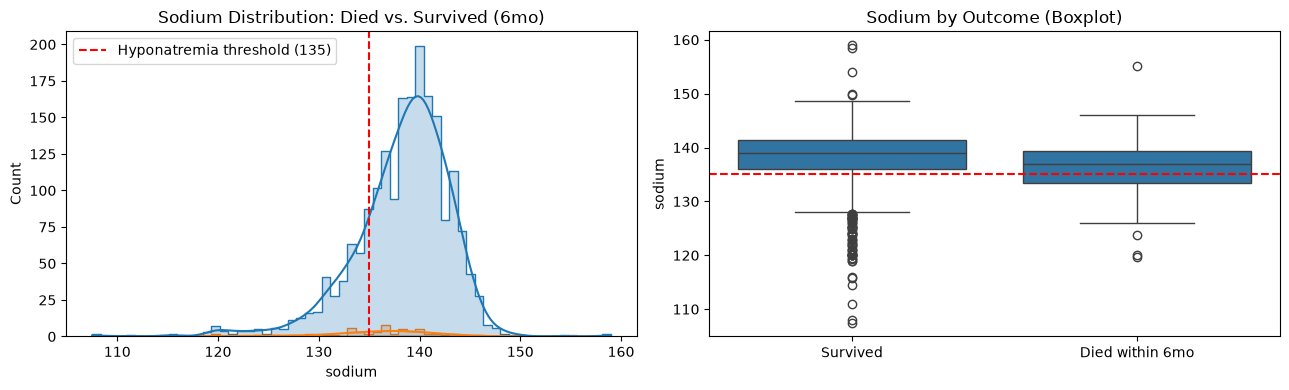

In [42]:
# Label the two groups
df_master['outcome_6m'] = df_master['death_within_6_months'].map({0: 'Survived', 1: 'Died within 6mo'})

# --- Summary stats ---
print(df_master.groupby('outcome_6m')['sodium'].describe())

# Proportion with low sodium (hyponatremia, <135 mmol/L) in each group
hyponatremia_rate = df_master.groupby('outcome_6m')['sodium'].apply(lambda x: (x < 135).mean() * 100)
print("\n% with hyponatremia (<135 mmol/L):")
print(hyponatremia_rate.round(2))

# --- Visualize: overlaid distributions ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=df_master, x='sodium', hue='outcome_6m', kde=True, element='step', ax=axes[0])
axes[0].axvline(135, color='red', linestyle='--', label='Hyponatremia threshold (135)')
axes[0].set_title('Sodium Distribution: Died vs. Survived (6mo)')
axes[0].legend()

sns.boxplot(data=df_master, x='outcome_6m', y='sodium', ax=axes[1])
axes[1].axhline(135, color='red', linestyle='--')
axes[1].set_title('Sodium by Outcome (Boxplot)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

**Insight:** Low sodium at admission nearly doubles the odds of 6-month mortality (34% of deaths vs. 19% of survivors), reflecting advanced heart failure where the body retains water faster than salt.
**Clinical significance:** Beyond serving as an early-warning marker for mortality risk, hyponatremia carries its own direct symptom burden — confusion, weakness, nausea, and in severe cases seizures.

## Q6.How many patients had high blood sugar levels when they were admitted, even if they weren't diagnosed diabetics?

**Reasoning:**
If a non-diabetic patient shows up with high blood sugar, it's basically a signal saying "this person's body is under serious stress" — Likely to have a heart failure later in their life

In [46]:
# Flag high glucose at admission (>7.8 mmol/L is the standard clinical cutoff for hyperglycemia)
high_glucose = df_master['glucose_blood_gas'] > 7.8

print(f"Overall % with high glucose: {high_glucose.mean()*100:.2f}%")


# Break down by diabetes diagnosis status (0 = not diabetic, 1 = diabetic)
non_diabetic_high = ((df_master['diabetes']==0) & high_glucose).sum()
total_non_diabetic = (df_master['diabetes']==0).sum()
print(f"\nNon-diabetics with high glucose: {non_diabetic_high} of {total_non_diabetic} "
      f"({non_diabetic_high/total_non_diabetic*100:.2f}%)")

diabetic_high = ((df_master['diabetes']==1) & high_glucose).sum()
total_diabetic = (df_master['diabetes']==1).sum()
print(f"Diabetics with high glucose: {diabetic_high} of {total_diabetic} "
      f"({diabetic_high/total_diabetic*100:.2f}%)")

Overall % with high glucose: 16.19%

Non-diabetics with high glucose: 182 of 1542 (11.80%)
Diabetics with high glucose: 143 of 466 (30.69%)


**Insight:** Roughly 1 in 9 non-diabetic patients showed elevated blood sugar at admission, suggesting acute physiological stress from the heart failure episode itself — a signal that could be missed since these patients have no prior diabetes diagnosis flagging them for monitoring.

## 7. How do clinical outcomes and hospital utilization vary across NYHA cardiac function classes?

**Reasoning:** 
NYHA class is supposed to reflect how sick a patient's heart failure has made them, so worse class should generally mean worse outcomes.

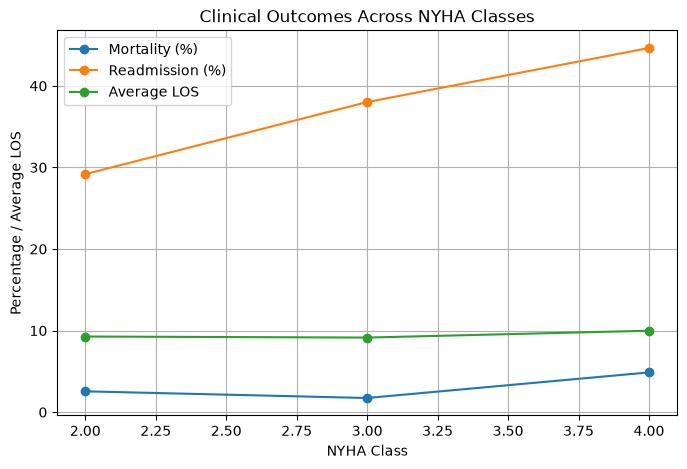

In [45]:
import matplotlib.pyplot as plt

# Create summary
summary = df_master.groupby('nyha_cardiac_function_classification').agg(
    mortality=('death_within_6_months', 'mean'),
    readmission=('re_admission_within_6_months', 'mean'),
    los=('dischargeday', 'mean')
)

# Convert rates to percentages
summary[['mortality', 'readmission']] *= 100

# Draw chart
summary[['mortality', 'readmission', 'los']].plot(
    marker='o',
    figsize=(8,5)
)

plt.title('Clinical Outcomes Across NYHA Classes')
plt.xlabel('NYHA Class')
plt.ylabel('Percentage / Average LOS')
plt.legend(['Mortality (%)', 'Readmission (%)', 'Average LOS'])
plt.grid(True)
plt.show()

**Insights:**
Readmission does get worse step by step with NYHA class (29% → 38% → 45%), but mortality and length of stay don't follow the same 
clean pattern — mortality actually dips at Class 3 before jumping at Class 4, and stay length barely changes at all.

## 8: What are the most common comorbidities (e.g., diabetes, hypertension, chronic kidney disease, COPD) present among admitted patients?


**Reasoning:**
Comorbidity burden shapes how complex a patient's care will be beyond their primary heart-failure diagnosis. Ranking these conditions by how often they
appear tells you which chronic diseases the care team is routinely managing alongside heart failure.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# List of true comorbidities — congestive_heart_failure is excluded because
# it's the primary admitting diagnosis, not a comorbidity, in a heart-failure cohort
comorbid_cols = [
    'diabetes', 'chronic_obstructive_pulmonary_disease', 'moderate_to_severe_chronic_kidney_disease',
    'cerebrovascular_disease', 'dementia', 'liver_disease', 'solid_tumor', 'malignant_lymphoma',
    'hemiplegia', 'aids', 'connective_tissue_disease', 'peptic_ulcer_disease',
    'myocardial_infarction', 'peripheral_vascular_disease'
]

# Calculate % prevalence and sort from most to least common
rates = (df_master[comorbid_cols].mean() * 100).sort_values(ascending=False)
print('Most common comorbidities (% of 2,008 patients):')
print(rates.round(1))

# Chart
fig, ax = plt.subplots(figsize=(9, 6))
rates.plot(kind='barh', ax=ax, color='#2a78d6')
ax.invert_yaxis()                                  # highest prevalence at the top
ax.set_xlabel('% of patients affected')
ax.set_title('Most common comorbidities among admitted patients')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Key Insight:**
Chronic kidney disease (23.6%) and diabetes (23.2%) dominate, each affecting roughly 1 in 4 patients 
together they're twice as common as the third-place condition (COPD, 11.6%). The remaining 11 comorbidities trail off sharply, 
from cerebrovascular disease at 7.5% down to malignant lymphoma at 0.0%, showing this cohort's added disease burden concentrates almost entirely in kidney and 
metabolic conditions rather than spreading evenly across categories.

## Q9.What are the baseline 28-day,3-month, and 6-month cumulative hospital readmission rates across the cohort?

**Reasoning:**
Readmission rate is a standard hospital quality metric, and every later comparison (by age, ward, comorbidity, or intervention) needs a baseline to be measured against. Without this number, you can't say whether any subgroup's risk is actually "elevated." It's also the foundation for prescriptive questions about follow-up timing and discharge planning.

In [ ]:
import pandas as pd

df_master = pd.read_csv("cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv")

total_patients = df_master['inpatient_number'].nunique()
readmit_cols = {
    '28-Day': 're_admission_within_28_days',
    '3-Month': 're_admission_within_3_months',
    '6-Month': 're_admission_within_6_months'
}

results = []
for label, col in readmit_cols.items():
    readmitted = df_master[col].sum()
    rate = (readmitted / total_patients) * 100
    results.append({
        'Timeframe': label,
        'Readmitted Patients': int(readmitted),
        'Total Patients': total_patients,
        'Readmission Rate (%)': round(rate, 2)
    })

readmission_summary = pd.DataFrame(results)
print(readmission_summary.to_string(index=False))

**Insights:**
The rate roughly triples between 28-day and 3-month (6.97% → 24.80%), then rises more gradually to 38.50% by 6 months. This steep early jump suggests most readmissions cluster in the 1-to-3-month window, a strong lead for a follow-up-timing recommendation.

## Q10.What are the central tendencies (mean, median) and spread of BNP,and what proportion of patients are above the normal diagnostic threshold (>100 pg/mL)?

**Reasoning:**
BNP is a key heart-failure severity marker, but lab values like this are often skewed, so mean alone can be misleading. Comparing mean vs. median reveals the shape of the distribution, and the threshold proportion converts a raw lab number into a clinically meaningful flag, which is more useful than an average on its own.

In [ ]:
bnp_col = 'brain_natriuretic_peptide'
bnp_data = df_master[bnp_col].dropna()

missing_pct = df_master[bnp_col].isna().mean() * 100
n_available = bnp_data.shape[0]
n_total = df_master.shape[0]

mean_bnp = bnp_data.mean()
median_bnp = bnp_data.median()
std_bnp = bnp_data.std()
q1, q3 = bnp_data.quantile([0.25, 0.75])
min_bnp, max_bnp = bnp_data.min(), bnp_data.max()

threshold = 100
above_threshold = (bnp_data > threshold).sum()
pct_above = (above_threshold / n_available) * 100

print(f"BNP available for {n_available} of {n_total} patients ({missing_pct:.1f}% missing)")
print(f"Mean: {mean_bnp:.1f} pg/mL")
print(f"Median: {median_bnp:.1f} pg/mL")
print(f"Std Dev: {std_bnp:.1f} pg/mL")
print(f"IQR (Q1-Q3): {q1:.1f} - {q3:.1f} pg/mL")
print(f"Min / Max: {min_bnp:.1f} / {max_bnp:.1f} pg/mL")
print(f"Patients above {threshold} pg/mL: {above_threshold} ({pct_above:.1f}%)")

**Insights:**
Mean (1,280) is far higher than median (753), confirming a right-skewed distribution driven by a subset of very high-BNP patients, so median better represents the "typical" patient. With 92.5% of patients already above the diagnostic threshold, BNP's value in this cohort lies less in the yes/no cutoff and more in tracking severity gradients above it.